# Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import json
from time import time
import pickle


# Import

In [4]:
df = pd.read_csv('FedSpeechesWithTime.csv', parse_dates = ['date','dateOnly'])
print(df.shape)
df['text'] = df['content'].astype(str)
df.head()


(7107, 83)


,District,MultSpeakers,VideoForm,Article,content,title,speaker,location,link,date,...,second_order_coherence,upStrain,board_role,IsBpres,title_main,name,dateOnly,timeOnly,score,text
0,Boston,0.0,False,False,"Economic Resilience, Amid Elevated Tariffs and...",Perspectives on the Economy from Susan M. Collins,Susan M. Collins,"Massachusetts towns of Fall River, New Bedford...",https://www.bostonfed.org/news-and-events/spee...,2025-06-25,...,0.511636,4.969992,Not Board,True,perspectives on the economy from susan m collins,susan collins,2025-06-25,NaN,NaN,"Economic Resilience, Amid Elevated Tariffs and..."
1,Boston,0.0,False,False,I am pleased to welcome all of you to the Fede...,Welcoming Remarks at the forum on “Meeting the...,Susan M. Collins,Federal Reserve Bank of Boston,https://www.bostonfed.org/news-and-events/spee...,2024-09-30,...,0.416154,5.349004,Not Board,True,welcoming remarks at the forum on meeting the ...,susan collins,2024-09-30,NaN,NaN,I am pleased to welcome all of you to the Fede...
2,Boston,0.0,False,False,Takeaways from Boston Fed President Susan M. C...,A Partnership for Progress,Susan M. Collins,"Lawrence, Massachusetts",https://www.bostonfed.org/news-and-events/spee...,2024-06-18,...,0.397782,4.661486,Not Board,True,a partnership for progress,susan collins,2024-06-18,NaN,NaN,Takeaways from Boston Fed President Susan M. C...
3,Boston,0.0,False,False,Boston Fed President and CEO Susan M. Collins'...,Reflections on Uncertainty and Patience in Mon...,Susan M. Collins,"Cambridge, Massachusetts",https://www.bostonfed.org/news-and-events/spee...,2024-05-08,...,0.446677,4.695629,Not Board,True,reflections on uncertainty and patience in mon...,susan collins,2024-05-08,NaN,NaN,Boston Fed President and CEO Susan M. Collins'...
4,Boston,1.0,True,False,"hi, good afternoon everyone. my name is Beth B...",Remarks for the National Association of Corpor...,Susan M. Collins,Federal Reserve Bank of Boston,https://www.bostonfed.org/news-and-events/spee...,2024-04-16,...,0.361304,5.368856,Not Board,True,remarks for the national association of corpor...,susan collins,2024-04-16,NaN,NaN,"hi, good afternoon everyone. my name is Beth B..."


In [5]:
shuffled_df = df.sample(frac=1, random_state=118712)
shuffled_df2 = shuffled_df.reset_index()
shuffled_df2


,index,District,MultSpeakers,VideoForm,Article,content,title,speaker,location,link,...,second_order_coherence,upStrain,board_role,IsBpres,title_main,name,dateOnly,timeOnly,score,text
0,6890,Chicago,NaN,False,False,SMALL ENTERPRISE CAPITAL ACCESS PARTNERSHIPS (...,[Speech Before the] Small Enterprise Capital A...,Michael H. Moskow,Federal Reserve Bank of Chicago,https://fraser.stlouisfed.org/title/statements...,...,0.345411,4.801816,Not Board,True,speech before the small enterprise capital acc...,michael moskow,1999-09-15,NaN,NaN,SMALL ENTERPRISE CAPITAL ACCESS PARTNERSHIPS (...
1,6038,Cleveland,NaN,False,False,Education Never Goes Out of Style 09.26.13 San...,Education Never Goes Out of Style,Sandra Pianalto,Federal Reserve Bank of Cleveland,https://www.clevelandfed.org/en/newsroom-and-e...,...,0.355128,4.279344,Not Board,True,education never goes out of style,sandra pianalto,2013-09-26,12:15:00,100.0,Education Never Goes Out of Style 09.26.13 San...
2,1678,Philadelphia,NaN,False,False,"Charles I Plosser: Shocks, gaps, and monetary ...","Shocks, gaps, and monetary policy",Charles I. Plosser,Federal Reserve Bank of Philadelphia,https://www.bis.org/review/r140113a.pdf,...,0.454721,4.736099,Not Board,True,shocks gaps and monetary policy,charles plosser,2014-01-04,17:00:00,100.0,"Charles I Plosser: Shocks, gaps, and monetary ..."
3,5699,Atlanta,NaN,False,False,THE INTERNATIONAL ECONOMIC OUTLOOK FOR 1994 Re...,The International Economic Outlook for 1994 : ...,Robert P Forrestal,Federal Reserve Bank of Atlanta,https://fraser.stlouisfed.org/files/docs/histo...,...,0.469119,4.493949,Not Board,False,the international economic outlook for 1994 r...,robert forrestal,1994-02-07,NaN,NaN,THE INTERNATIONAL ECONOMIC OUTLOOK FOR 1994 Re...
4,298,BoardGovernors,0.0,False,False,I am grateful for the educational opportunitie...,What Will Artificial Intelligence Mean for Ame...,Lisa D. Cook,"At The Ohio State University, Columbus, Ohio",https://www.federalreserve.gov/newsevents/spee...,...,0.485275,4.650504,Governor,False,what will artificial intelligence mean for ame...,lisa cook,2024-09-26,NaN,NaN,I am grateful for the educational opportunitie...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7102,4695,Kansas,NaN,False,False,Maintaining Stability in a Changing Financial ...,Maintaining Stability in a Changing Financial ...,Thomas M. Hoenig,Federal Reserve Bank of Kansas City,https://www.kansascityfed.org/documents/2204/H...,...,0.495487,4.327230,Not Board,True,maintaining stability in a changing financial ...,thomas hoenig,2007-11-06,NaN,NaN,Maintaining Stability in a Changing Financial ...
7103,3310,Boston,NaN,False,False,"EMBARGOED UNTIL October 18, 2014 at 8:30 Can E...",Can Economic Opportunity Flourish When Communi...,Eric S. Rosengren,Federal Reserve Bank of Boston,https://www.bostonfed.org/news-and-events/spee...,...,0.428881,5.066549,Not Board,True,can economic opportunity flourish when communi...,eric rosengren,2014-10-18,08:30:00,100.0,"EMBARGOED UNTIL October 18, 2014 at 8:30 Can E..."
7104,1909,NewYork,NaN,False,False,Kevin Stiroh: The theory and practice of super...,The theory and practice of supervision,Kevin Stiroh,Federal Reserve Bank of New York,https://www.bis.org/review/r160418a.htm,...,0.441783,4.358094,Not Board,False,the theory and practice of supervision,kevin stiroh,2016-04-11,NaN,NaN,Kevin Stiroh: The theory and practice of super...
7105,3467,BoardGovernors,NaN,False,False,Remarks by Chairman Alan Greenspan At the Fede...,Banking in the global marketplace,Alan Greenspan,Board of Governors of the Federal Reserve,https://www.federalreserve.gov/boarddocs/speec...,...,0.449692,4.715885,Chair,False,banking in the global marketplace,alan greenspan,1996-11-18,NaN,NaN,Remarks by Chairman Alan Greenspan At the Fede...


In [6]:
with open("tokenized_statements_lemmas_ngrams_cleaned", "rb") as fp:   # Unpickling
    tokenized = pickle.load(fp)
print(len(tokenized))
tokenized[:2]


7107


[['small',
  'enterprise',
  'capital',
  'access',
  'partnerships',
  'secap',
  'federal',
  '_reserve_bank_of_chicago_',
  'chicago',
  'illinois',
  'september',
  '15',
  '1999',
  'i.',
  '_good_morning_',
  'pleased',
  'welcome',
  'today',
  'formally',
  'kick',
  'small',
  'enterprise',
  'capital',
  'access',
  'partnership',
  'secap',
  'a.',
  'talk',
  'initiative',
  'like',
  'recognize',
  'organization',
  'agree',
  'co-convene',
  'secap',
  'federal',
  'reser',
  '_bank_of_chicago_',
  'secap',
  'co-convener',
  'include',
  'chicago',
  'association',
  'neighborhood',
  'development',
  'organizations',
  'good',
  'know',
  'cando',
  'womens',
  'business',
  'development',
  'center',
  'chicago',
  'district',
  'office',
  'u.s.',
  'sba',
  'chicagoland',
  '_chamber_of_commerce_',
  'illinois',
  '_bankers_association_',
  'cosmopolitan',
  '_chamber_of_commerce_',
  'b.',
  'will',
  'hearing',
  'representative',
  'organization',
  'late',
  'mor

In [7]:
# Add tokenized column
shuffled_df2["tokens"] = tokenized
shuffled_df2[["content","tokens"]].head(20)


,content,tokens
0,SMALL ENTERPRISE CAPITAL ACCESS PARTNERSHIPS (...,"[small, enterprise, capital, access, partnersh..."
1,Education Never Goes Out of Style 09.26.13 San...,"[education, never, go, style, 09.26.13, _sandr..."
2,"Charles I Plosser: Shocks, gaps, and monetary ...","[__charles_i_plosser_, shocks, gap, monetary, ..."
3,THE INTERNATIONAL ECONOMIC OUTLOOK FOR 1994 Re...,"[international, _economic_outlook_, 1994, _rem..."
4,I am grateful for the educational opportunitie...,"[grateful, educational, opportunity, universit..."
5,Understanding Monetary Policy Through the Hous...,"[understanding, _monetary_policy_, housing, ch..."
6,Jerome H Powell: Treasury markets and the TMPG...,"[__jerome_h_powell_, _treasury_market_, tmpg, ..."
7,"Remarks by Vice Chairman Roger W. Ferguson, Jr...","[remark, _vice_chair_man_, _roger_w._ferguson_..."
8,Alan Greenspan: Follow-up to the semiannual mo...,"[__alan_greenspan_, follow, _semiannual_moneta..."
9,Director Abigail Wozniak on the Women in Econo...,"[director, abigail, wozniak, woman, economics,..."


# The world cloud

## Some processing (numbers removal)

In [9]:
def final_clean(tokens):
    cleaned = []
    for t in tokens:
        # remove pure numbers
        if t.isdigit():
            continue

        # remove things that contain only digits and special characters
        if re.search(r"\d", t) and re.search(r"\D", t):
            continue
        
        # remove contraction fragments
        if t in {"s", "t", "ll", "ve", "re", "d"}:
            continue

        cleaned.append(t)
    return cleaned

shuffled_df2["final_tokens"] = shuffled_df2["tokens"].apply(final_clean)
shuffled_df2[["content","tokens","final_tokens"]].head(20)


,content,tokens,final_tokens
0,SMALL ENTERPRISE CAPITAL ACCESS PARTNERSHIPS (...,"[small, enterprise, capital, access, partnersh...","[small, enterprise, capital, access, partnersh..."
1,Education Never Goes Out of Style 09.26.13 San...,"[education, never, go, style, 09.26.13, _sandr...","[education, never, go, style, _sandra_pianalto..."
2,"Charles I Plosser: Shocks, gaps, and monetary ...","[__charles_i_plosser_, shocks, gap, monetary, ...","[__charles_i_plosser_, shocks, gap, monetary, ..."
3,THE INTERNATIONAL ECONOMIC OUTLOOK FOR 1994 Re...,"[international, _economic_outlook_, 1994, _rem...","[international, _economic_outlook_, _remark_by..."
4,I am grateful for the educational opportunitie...,"[grateful, educational, opportunity, universit...","[grateful, educational, opportunity, universit..."
5,Understanding Monetary Policy Through the Hous...,"[understanding, _monetary_policy_, housing, ch...","[understanding, _monetary_policy_, housing, ch..."
6,Jerome H Powell: Treasury markets and the TMPG...,"[__jerome_h_powell_, _treasury_market_, tmpg, ...","[__jerome_h_powell_, _treasury_market_, tmpg, ..."
7,"Remarks by Vice Chairman Roger W. Ferguson, Jr...","[remark, _vice_chair_man_, _roger_w._ferguson_...","[remark, _vice_chair_man_, _roger_w._ferguson_..."
8,Alan Greenspan: Follow-up to the semiannual mo...,"[__alan_greenspan_, follow, _semiannual_moneta...","[__alan_greenspan_, follow, _semiannual_moneta..."
9,Director Abigail Wozniak on the Women in Econo...,"[director, abigail, wozniak, woman, economics,...","[director, abigail, wozniak, woman, economics,..."


## World cloud with some restrictions

In [24]:
# This is the functions needed
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

def plot_tfidf_wordcloud(token_lists, 
                         title="TF-IDF Word Cloud",
                         min_df=0.01, 
                         max_df=0.8,
                         keep_ratio=1.0,
                         custom_stopwords=None,
                         figsize=(6,4)):
    """
    token_lists: list of lists of tokens (one list per document)
    keep_ratio: keep top X% of TF-IDF terms (1.0 = keep all)
    """

    docs = [" ".join(tokens) for tokens in token_lists]

    vectorizer = TfidfVectorizer(
        min_df=min_df,
        max_df=max_df,
        ngram_range=(1, 4),
        sublinear_tf=True,
        stop_words=custom_stopwords
    )

    tfidf_matrix = vectorizer.fit_transform(docs)

    scores = np.asarray(tfidf_matrix.sum(axis=0)).ravel()
    vocab = vectorizer.get_feature_names_out()
    tfidf_scores = dict(zip(vocab, scores))

    if keep_ratio < 1.0:
        sorted_items = sorted(tfidf_scores.items(), key=lambda x: x[1], reverse=True)
        keep_n = int(len(sorted_items) * keep_ratio)
        tfidf_scores = dict(sorted_items[:keep_n])

    wc = WordCloud(width=800, height=500, background_color="white")
    wc.generate_from_frequencies(tfidf_scores)

    plt.figure(figsize=figsize)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=14)
    plt.savefig("Graphs/WordCloud/"+title+".png", bbox_inches="tight")
    plt.show()
    

### Overall

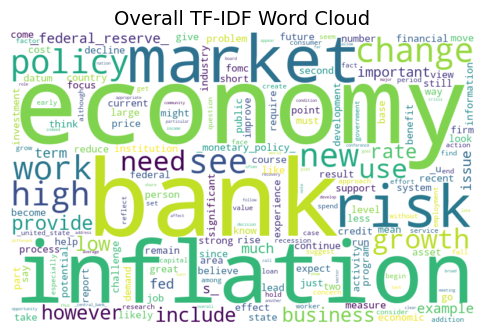

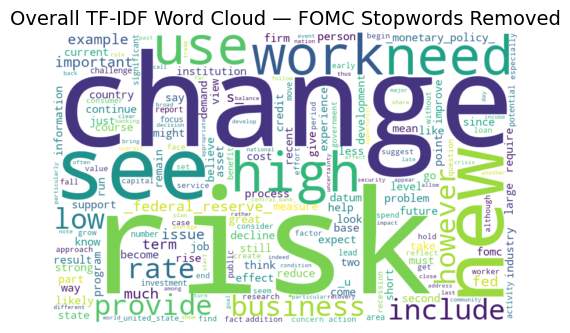

In [26]:
# This is for all observations
fomc_stopwords = [
    "federal", "reserve", "bank", "banks", "system", "committee", "board",
    "monetary", "policy", "policies", "economic", "economy", "financial",
    "inflation", "employment", "labor", "market", "growth", "rates",
    "price", "stability", "conditions", "outlook", "sector", "global",
    "thank", "today", "conference", "meeting", "remarks"
]
time_stopwords = [
    "year", "years", "month", "months", "week", "weeks",
    "today", "yesterday", "tomorrow", "quarter", "quarters"
]

plot_tfidf_wordcloud(
    shuffled_df2["final_tokens"].tolist(),
    title="Overall TF-IDF Word Cloud",
    min_df=0.01,
    max_df=0.8,
    keep_ratio=0.8,   # keep top 80% of words
    custom_stopwords=time_stopwords,
    figsize=(6,4)
)

plot_tfidf_wordcloud(
    shuffled_df2["final_tokens"].tolist(),
    title="Overall TF-IDF Word Cloud — FOMC Stopwords Removed",
    min_df=0.01,
    max_df=0.8,
    keep_ratio=0.8,   # keep top 80% of words
    custom_stopwords=fomc_stopwords+time_stopwords,
    figsize=(6,4)
)



### For specific group

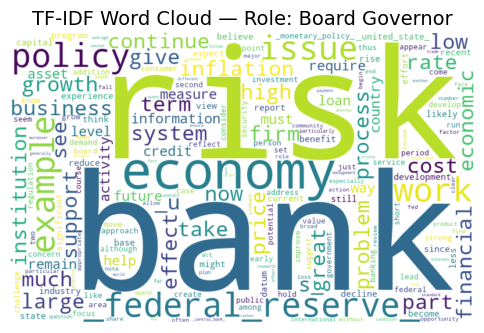

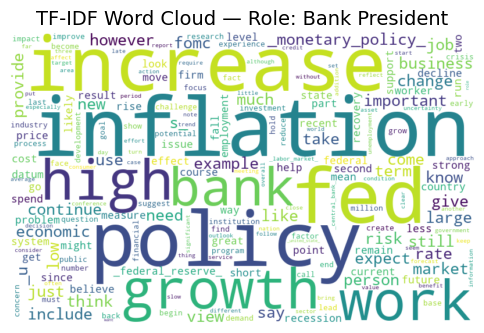

In [72]:
# this is for specific groups
dum = {True:"Bank President", False:"Board Governor"}
for role, group in shuffled_df2.groupby("IsBpres"):
    plot_tfidf_wordcloud(
        group["final_tokens"].tolist(),
        title=f"TF-IDF Word Cloud — Role: {dum[role]}",
        min_df=0.01,
        max_df=0.8,
        keep_ratio=0.8,
        custom_stopwords=time_stopwords,
        figsize=(6,4)
    )
    

### For high/low complexity

In [28]:
# First i need the complexity measurements!
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def bartlettSphericity(df, pthreshold = 0.05):
    chi_square_value, p_value = calculate_bartlett_sphericity(df)
    print("The p-value = "+ str(p_value))
    if p_value <pthreshold:
        print('Significant at 5%, the observered matrix is not an identity matrix')
    else:
        print('There are likely little correlation')
    return p_value

def getPC(df, varList, numComp):
    df = df.reset_index(drop=True)
    dfPrep = df[varList].copy()
    # need to drop missing value if any
    dfPrep = dfPrep.dropna()
    indexNonM = dfPrep.index.tolist()
    
    XScaled = StandardScaler().fit_transform(dfPrep.values)
    dfXScaled = pd.DataFrame(XScaled, index=dfPrep.index, columns=dfPrep.columns)
    
    pca = PCA(n_components=numComp)
    pca_features = pca.fit_transform(XScaled)
 
    pca_df = pd.DataFrame(
        data=pca_features, 
        columns=['PC'+str(i+1) for i in range(numComp)])
    pca_df.index = indexNonM
    
    res = df.join(pca_df)
    return res

def combineVar(df, varList, numComp, name, drop= True, printBartlett = True, printCorr = False, printMissing = False):
    if name in df.columns.tolist():
        df = df.drop(columns = [name])
    df0 = df[varList].copy()
    if printBartlett:
        bartP = bartlettSphericity(df0.dropna(), pthreshold = 0.05)
    if printMissing:
        print(df0.isnull().sum())

    df1 = getPC(df, varList, numComp)
    df1.rename(columns = {'PC1':name}, inplace = True)

    if printCorr:
        print(df1[varList+[name]].corr()[[name]])
    if drop:
        df1.drop(columns = varList, inplace = True)
    if printBartlett:
        return df1, bartP
    else:
        return df1



In [29]:
varMegaList = [['concreteness', 'concretenessExtra', 'concreteRatio', 'concreteMean', 'concrete25', 'concreteMeanExtra', 'concrete25Extra'],
               ['entropy'],
               ['flesch_reading_ease', 'flesch_kincaid_grade', 'smog', 'gunning_fog', 'automated_readability_index', 'coleman_liau_index', 'lix', 'rix'],
               ['first_order_coherence', 'second_order_coherence'],
               ['dependency_distance_mean'],
               ['upStrain']
              ]
allvar = varMegaList[0]
for i in varMegaList[1:]:
    allvar = allvar+i
nameList = ['abstract','info','read','disunity','strain','strainUpper']
shuffled_df2[allvar].isnull().sum()


concreteness                   0
concretenessExtra              0
concreteRatio                  0
concreteMean                   0
concrete25                     0
concreteMeanExtra              0
concrete25Extra                0
entropy                        0
flesch_reading_ease            0
flesch_kincaid_grade           0
smog                           0
gunning_fog                    0
automated_readability_index    0
coleman_liau_index             0
lix                            0
rix                            0
first_order_coherence          0
second_order_coherence         0
dependency_distance_mean       0
upStrain                       0
dtype: int64

In [30]:
dfPC = shuffled_df2.copy()

for var in [i for i in varMegaList[0] if i not in ['concreteRatio']]:
    dfPC[var+'flip'] = 6-dfPC[var]
dfPC['concreteRatioflip'] = 1/dfPC['concreteRatio'] #according to the summary stat, there is no 0
varMegaList[0] = [i+'flip' for i in varMegaList[0]]

numComp = 1
for i in range(len(nameList)):
    varList = varMegaList[i]
    name = nameList[i]
    print(name)
    if len(varList) == 1:
        dfPC = combineVar(dfPC, varList, numComp, name, drop= False, printBartlett = False, printCorr = False, printMissing = False)
    else:
        dfPC, pvalue = combineVar(dfPC, varList, numComp, name, drop= False, printBartlett = True, printCorr = True, printMissing = True)

# PC for readability suddenly side with the flesch reading ease so i have to flip the sign
dfPC['read'] = -dfPC['read']


abstract
The p-value = 0.0
Significant at 5%, the observered matrix is not an identity matrix
concretenessflip         0
concretenessExtraflip    0
concreteRatioflip        0
concreteMeanflip         0
concrete25flip           0
concreteMeanExtraflip    0
concrete25Extraflip      0
dtype: int64
                       abstract
concretenessflip       0.906394
concretenessExtraflip  0.796004
concreteRatioflip      0.815175
concreteMeanflip       0.906394
concrete25flip         0.906394
concreteMeanExtraflip  0.796004
concrete25Extraflip    0.796004
abstract               1.000000
info
read
The p-value = 0.0
Significant at 5%, the observered matrix is not an identity matrix
flesch_reading_ease            0
flesch_kincaid_grade           0
smog                           0
gunning_fog                    0
automated_readability_index    0
coleman_liau_index             0
lix                            0
rix                            0
dtype: int64
                                 read
flesch

C:\Users\Lynn\anaconda3\Lib\site-packages\factor_analyzer\factor_analyzer.py:109: RuntimeWarning: divide by zero encountered in log
  statistic = -np.log(corr_det) * (n - 1 - (2 * p + 5) / 6)


In [31]:
# simple correlations
mainVar = ['abstract','info','read','disunity','strain','strainUpper']
dfcheck = dfPC[mainVar]
with pd.option_context("display.max_columns", None):
    display(dfcheck.corr())



,abstract,info,read,disunity,strain,strainUpper
abstract,1.000000,0.104591,0.259190,0.278646,0.242464,0.118068
info,0.104591,1.000000,0.006299,0.102054,0.118538,0.187227
read,0.259190,0.006299,1.000000,0.671491,0.723864,0.498049
disunity,0.278646,0.102054,0.671491,1.000000,0.819330,0.382003
strain,0.242464,0.118538,0.723864,0.819330,1.000000,0.558255
strainUpper,0.118068,0.187227,0.498049,0.382003,0.558255,1.000000


#### complexity measurements


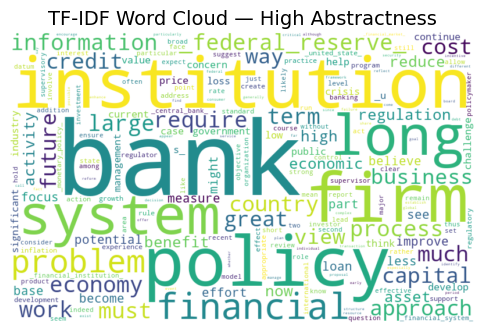

In [45]:
# this is for complexity
threshold = dfPC["abstract"].quantile(0.8)
high_df = dfPC[dfPC["abstract"] >= threshold]

plot_tfidf_wordcloud(
    high_df["final_tokens"].tolist(),
    title="TF-IDF Word Cloud — High Abstractness",
    min_df=0.01,
    max_df=0.8,
    keep_ratio=0.8,
    custom_stopwords=time_stopwords,
    figsize=(6,4)
)


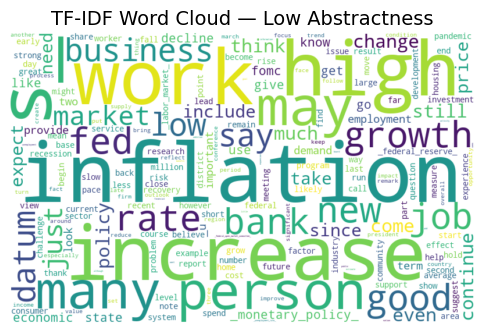

In [46]:
# this is for complexity
threshold = dfPC["abstract"].quantile(0.2)
low_df = dfPC[dfPC["abstract"] <= threshold]

plot_tfidf_wordcloud(
    low_df["final_tokens"].tolist(),
    title="TF-IDF Word Cloud — Low Abstractness",
    min_df=0.01,
    max_df=0.8,
    keep_ratio=0.8,
    custom_stopwords=time_stopwords,
    figsize=(6,4)
)

In [49]:
print(dfPC.columns.tolist())


['index', 'District', 'MultSpeakers', 'VideoForm', 'Article', 'content', 'title', 'speaker', 'location', 'link', 'date', 'positiveFin', 'neutralFin', 'negativeFin', 'hawkishMal', 'n_hawk_pair', 'n_dove_pair', 'concreteness', 'concretenessExtra', 'concreteRatio', 'concreteMean', 'concrete25', 'concreteMeanExtra', 'concrete25Extra', 'token_length_mean', 'token_length_median', 'token_length_std', 'sentence_length_mean', 'sentence_length_median', 'sentence_length_std', 'syllables_per_token_mean', 'syllables_per_token_median', 'syllables_per_token_std', 'n_tokens', 'n_unique_tokens', 'proportion_unique_tokens', 'n_characters', 'n_sentences', 'entropy', 'perplexity', 'per_word_perplexity', 'dependency_distance_mean', 'dependency_distance_std', 'prop_adjacent_dependency_relation_mean', 'prop_adjacent_dependency_relation_std', 'passed_quality_check', 'n_stop_words', 'alpha_ratio', 'mean_word_length', 'doc_length', 'symbol_to_word_ratio_#', 'proportion_ellipsis', 'proportion_bullet_points', 'co

In [65]:
x = 'abn'
x.capitalize()

'Abn'

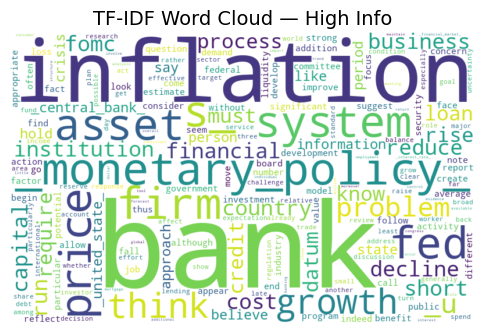

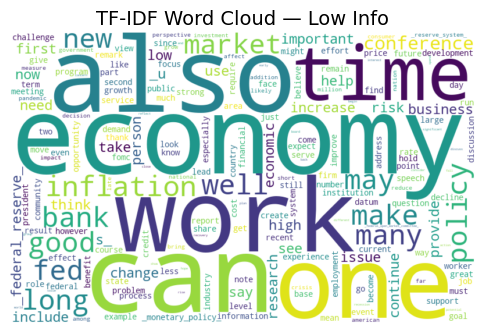

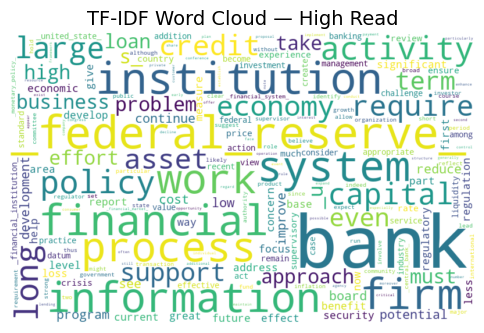

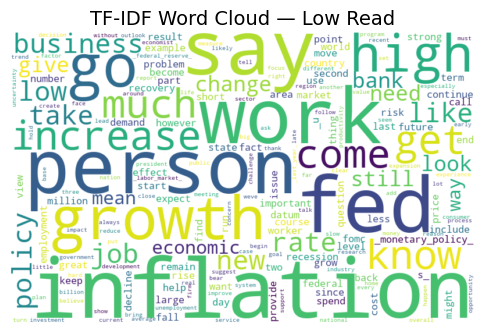

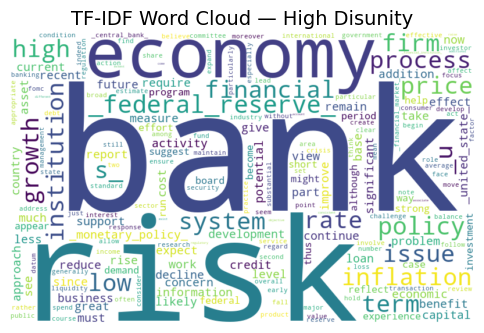

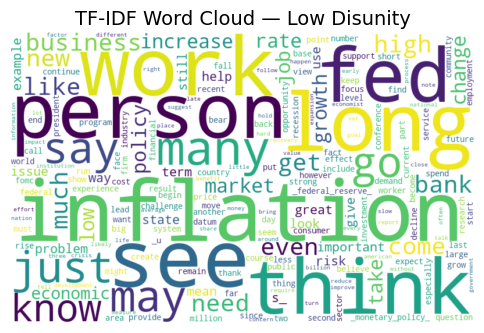

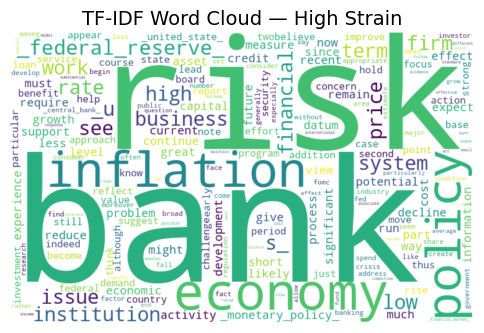

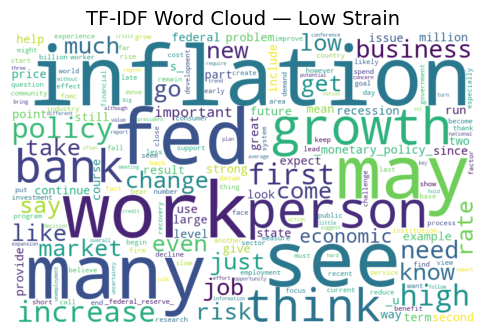

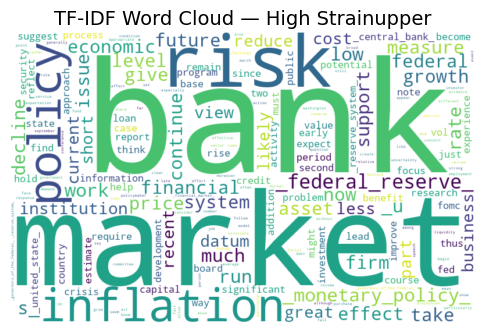

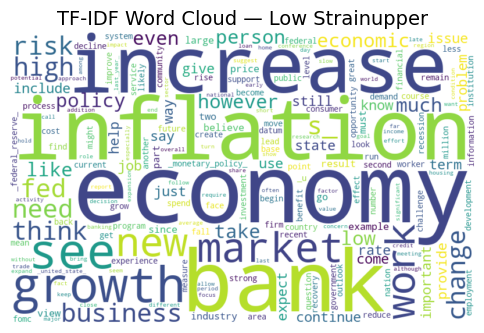

In [67]:
# do it for the rest and pick

# this is for complexity
complexList = ['info', 'read', 'disunity', 'strain', 'strainUpper']
for var in complexList:
    threshold = dfPC[var].quantile(0.8)
    high_df = dfPC[dfPC[var] >= threshold]
    
    plot_tfidf_wordcloud(
        high_df["final_tokens"].tolist(),
        title="TF-IDF Word Cloud — High "+var.capitalize(),
        min_df=0.01,
        max_df=0.8,
        keep_ratio=0.8,
        custom_stopwords=time_stopwords,
        figsize=(6,4)
    )

    threshold = dfPC[var].quantile(0.2)
    low_df = dfPC[dfPC[var] <= threshold]
    
    plot_tfidf_wordcloud(
        low_df["final_tokens"].tolist(),
        title="TF-IDF Word Cloud — Low "+var.capitalize(),
        min_df=0.01,
        max_df=0.8,
        keep_ratio=0.8,
        custom_stopwords=time_stopwords,
        figsize=(6,4)
    )



#### Alan Greenspan

(494, 100)


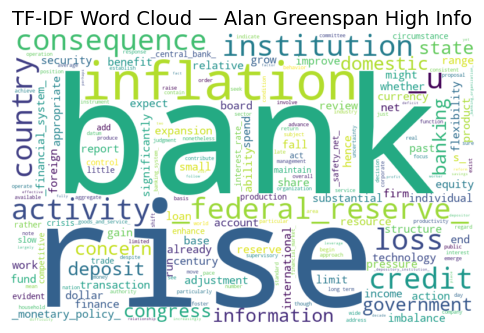

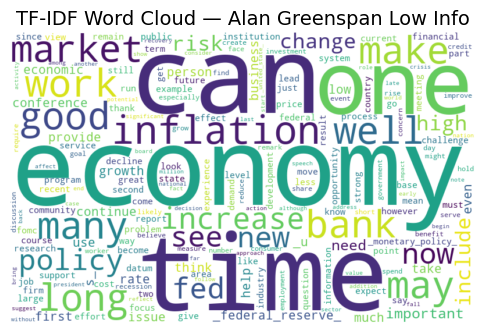

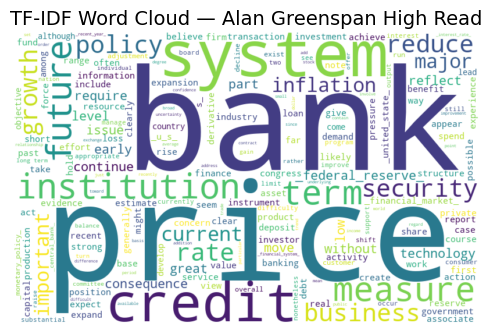

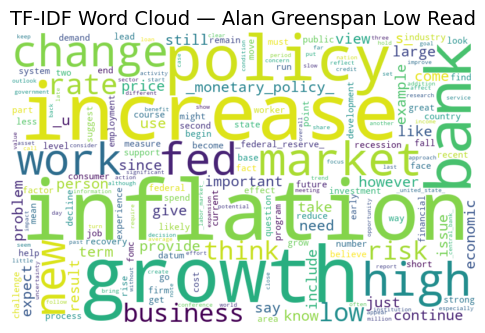

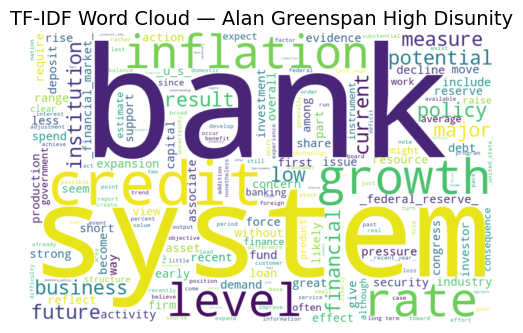

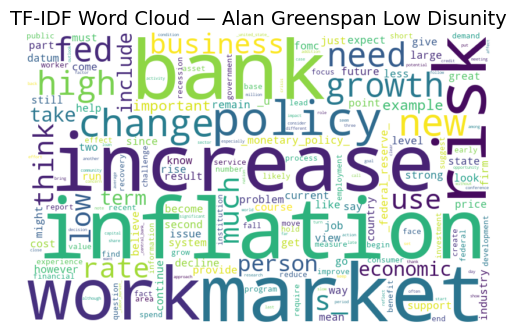

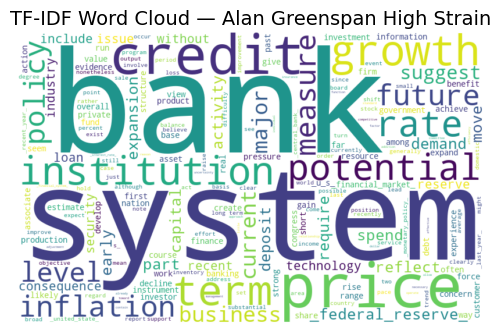

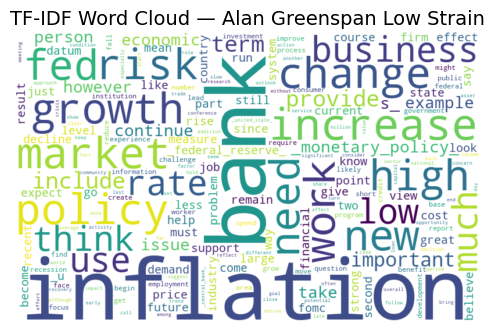

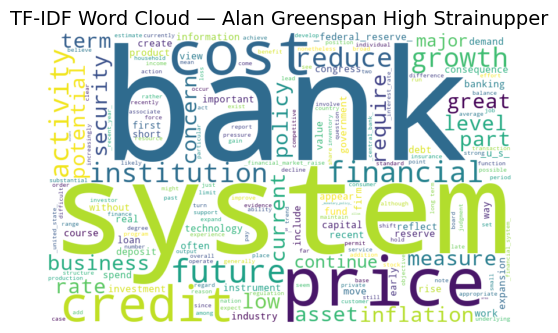

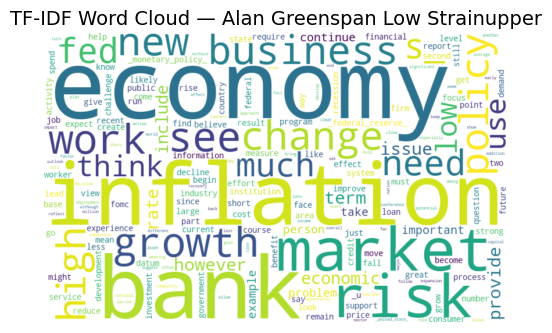

In [78]:
dfAlan = dfPC[dfPC["speaker"] == "Alan Greenspan"]
print(dfAlan.shape)

# this is for complexity
complexList = ['info', 'read', 'disunity', 'strain', 'strainUpper']
for var in complexList:
    threshold = dfAlan[var].quantile(0.85)
    high_df = dfAlan[dfAlan[var] >= threshold]
    
    plot_tfidf_wordcloud(
        high_df["final_tokens"].tolist(),
        title="TF-IDF Word Cloud — Alan Greenspan High "+var.capitalize(),
        min_df=0.01,
        max_df=0.8,
        keep_ratio=0.8,
        custom_stopwords=time_stopwords,
        figsize=(6,4)
    )

    threshold = dfAlan[var].quantile(0.3)
    low_df = dfPC[dfPC[var] <= threshold]
    
    plot_tfidf_wordcloud(
        low_df["final_tokens"].tolist(),
        title="TF-IDF Word Cloud — Alan Greenspan Low "+var.capitalize(),
        min_df=0.01,
        max_df=0.8,
        keep_ratio=0.8,
        custom_stopwords=time_stopwords,
        figsize=(6,4)
    )



### Others